In [ ]:
# -*- coding: utf-8 -*-
"""yolov8n and CBAM.ipynb


Automatically generated by Colab.


Original file is located at
    https://colab.research.google.com/drive/1ODU-EyLGXvgKhFWJ1LIbuRMZgiE684cn
"""


# ============================================================
# YOLOv8n + CBAM
# ============================================================





# -------------------- Install Ultralytics --------------------
!pip install ultralytics -q


# -------------------- Imports --------------------
import os
import torch
import torch.nn as nn
import pandas as pd
from ultralytics import YOLO





OUT = "/content/drive/MyDrive/Major_Project/10_classes_YOLO_Cbam_Architecture/Results"




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# ============================================================
# CREATE DATA.YAML
# ============================================================

yaml_content = """
path: /content/drive/MyDrive/Major_Project/Images2700_10Feet_Detected
train: images/train
val: images/val


nc: 3
names:
  0: Speed_Breaker
  1: Slippery_Road
  2: school_zone
"""


os.makedirs(OUT, exist_ok=True)


with open(f"{OUT}/data.yaml", "w") as f:
    f.write(yaml_content)


print("✅ data.yaml created")




✅ data.yaml created


In [ ]:
# ============================================================
# CREATE CBAM MODULE
# ============================================================


class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)


        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )


        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)




class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))




class CBAM(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.ca = ChannelAttention(in_channels)
        self.sa = SpatialAttention()


    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x


print("✅ CBAM module created")




✅ CBAM module created


In [ ]:
# ============================================================
# REGISTER CBAM INTO YOLO
# ============================================================

import ultralytics.nn.tasks as tasks
import ultralytics.nn.modules as modules

tasks.CBAM = CBAM
modules.CBAM = CBAM

print("✅ CBAM registered")

✅ CBAM registered


In [ ]:
# ============================================================
# CREATE CUSTOM YOLOv8 YAML
# ============================================================

model_yaml = """
nc: 3
depth_multiple: 0.33
width_multiple: 0.25

backbone:
  [
    [-1, 1, Conv, [64, 3, 2]],
    [-1, 1, Conv, [128, 3, 2]],
    [-1, 3, C2f, [128, True]],
    [-1, 1, Conv, [256, 3, 2]],
    [-1, 6, C2f, [256, True]],
    [-1, 1, Conv, [512, 3, 2]],
    [-1, 6, C2f, [512, True]],
    [-1, 1, Conv, [1024, 3, 2]],
    [-1, 3, C2f, [1024, True]],
    [-1, 1, CBAM, [256]],
    [-1, 1, SPPF, [1024, 5]],
  ]

head:
  [
    [-1, 1, nn.Upsample, [None, 2, nearest]],
    [[-1, 6], 1, Concat, [1]],
    [-1, 3, C2f, [512]],
    [-1, 1, nn.Upsample, [None, 2, nearest]],
    [[-1, 4], 1, Concat, [1]],
    [-1, 3, C2f, [256]],
    [-1, 1, Conv, [256, 3, 2]],
    [[-1, 13], 1, Concat, [1]],
    [-1, 3, C2f, [512]],
    [-1, 1, Conv, [512, 3, 2]],
    [[-1, 10], 1, Concat, [1]],
    [-1, 3, C2f, [1024]],
    [[16, 19, 22], 1, Detect, [nc]],
  ]
"""

with open(f"{OUT}/yolov8n_cbam.yaml", "w") as f:
    f.write(model_yaml)

print("✅ Custom model YAML created")

✅ Custom model YAML created


In [ ]:
# ============================================================
# LOAD MODEL
# ============================================================

model = YOLO(f"{OUT}/yolov8n_cbam.yaml")

# Load pretrained weights
model.load("yolov8n.pt")

print("✅ Model loaded")

Transferred 150/358 items from pretrained weights
✅ Model loaded


In [ ]:
import torch
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Using: {'GPU ✅' if device == 0 else 'CPU ⚠️'}")

Using: GPU ✅


In [ ]:
# ============================================================
# TRAIN MODEL
# ============================================================

print("\n🚀 START TRAINING\n")

results = model.train(
    data=f"{OUT}/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    project=OUT,
    name="yolov8n_cbam",
    device=0,
    plots=True,
    verbose=True
)

print("\n✅ Training Completed")


🚀 START TRAINING

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam.yaml, momentum=0.937, mosaic=1.0

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/20      1.99G      2.229      2.849      3.351         24        640: 100% ━━━━━━━━━━━━ 169/169 1.6it/s 1:45
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.2it/s 6.6s
                   all        240        240      0.634       0.45      0.615      0.351

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/20      2.46G      1.359      1.683      2.337         41        640: 0% ──────────── 0/169  0.2s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/20      2.47G      1.276      1.567       2.01         22        640: 100% ━━━━━━━━━━━━ 169/169 1.9it/s 1:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.8it/s 2.9s
                   all        240        240      0.794      0.834      0.916      0.707

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/20      2.47G      1.083      1.214      1.777         46        640: 0% ──────────── 0/169  0.2s

...

      18/20      2.53G     0.4108     0.2292      1.077         11        640: 100% ━━━━━━━━━━━━ 169/169 1.8it/s 1:32
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.8it/s 2.8s
                   all        240        240      0.998          1      0.995      0.912

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      19/20      2.53G     0.4922     0.2756      1.141         16        640: 0% ──────────── 0/169  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      19/20      2.53G     0.4021     0.2178      1.072         11        640: 100% ━━━━━━━━━━━━ 169/169 1.8it/s 1:32
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.0it/s 2.6s
                   all        240        240      0.998          1      0.995      0.917

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/20      2.53G     0.5094     0.2324      1.176         16        640: 0% ──────────── 0/169  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      20/20      2.53G     0.3932     0.2112      1.059         11        640: 100% ━━━━━━━━━━━━ 169/169 1.9it/s 1:31
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.8it/s 4.3s
                   all        240        240      0.998          1      0.995       0.92

20 epochs completed in 0.530 hours.
Optimizer stripped from /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/last.pt, 6.2MB
Optimizer stripped from /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/best.pt, 6.2MB

Validating /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/best.pt...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n_cbam summary (fused): 81 layers, 3,014,523 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%

In [ ]:
from ultralytics import YOLO

# Load your saved .pt model from Drive
model = YOLO('/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/best.pt')  # update path

# Export to ONNX
model.export(format='onnx')
print("✅ ONNX export done!")

# Export to TFLite
model.export(format='tflite')
print("✅ TFLite export done!")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n_cbam summary (fused): 81 layers, 3,014,523 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 195ms
Prepared 4 packages in 4.39s
Installed 4 packages in 373ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.1
 + onnxslim==0.1.85

requirements: AutoUpdate success ✅ 5.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONN

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.85...
ONNX: export success ✅ 9.1s, saved as '/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/best.onnx' (11.7 MB)

Export complete (9.5s)
Results saved to /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/best.onnx imgsz=640 data=/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/data.yaml  
Visualize:       https://netron.app
✅ ONNX export done!
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv8n_cbam summary (fused): 81 layers, 3,014,523 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Major_Proj

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.85...
ONNX: export success ✅ 1.2s, saved as '/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/best.onnx' (11.8 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 48.0files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 7, 8400), dtype=tf.float32, name=None)
Captures:
  133320745063952: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  133320745062416: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  133320745063184: TensorSpec(shap

In [ ]:
# ===================== INSTALL & IMPORT =====================
!pip install ultralytics -q


from ultralytics import YOLO

print("✅ YOLO imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLO imported successfully


✅ CBAM registered
🎯 YOLO-CBAM MODEL - COMPLETE ANALYSIS WITH 10 KEY METRICS

📂 Configuration:
   Training Results : /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results
   Dataset          : /content/drive/MyDrive/Major_Project/Images2700_10Feet_Detected
   Test Output      : /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/test_analysis_resultsinplot
   Model Weights    : /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results/yolov8n_cbam/weights/best.pt

📊 PART 1: TRAINING HISTORY (Epoch-by-Epoch Metrics)

Training Metrics for All Epochs:
--------------------------------------------------------------------------------------------------------------
Epoch    Train Loss      Val Loss        Val mAP50       Val mAP50-95    Precision       Recall         
--------------------------------------------------------------------------------------------------------------
1        2.2289          1.5313          0.6153          0.3509          0.6338        

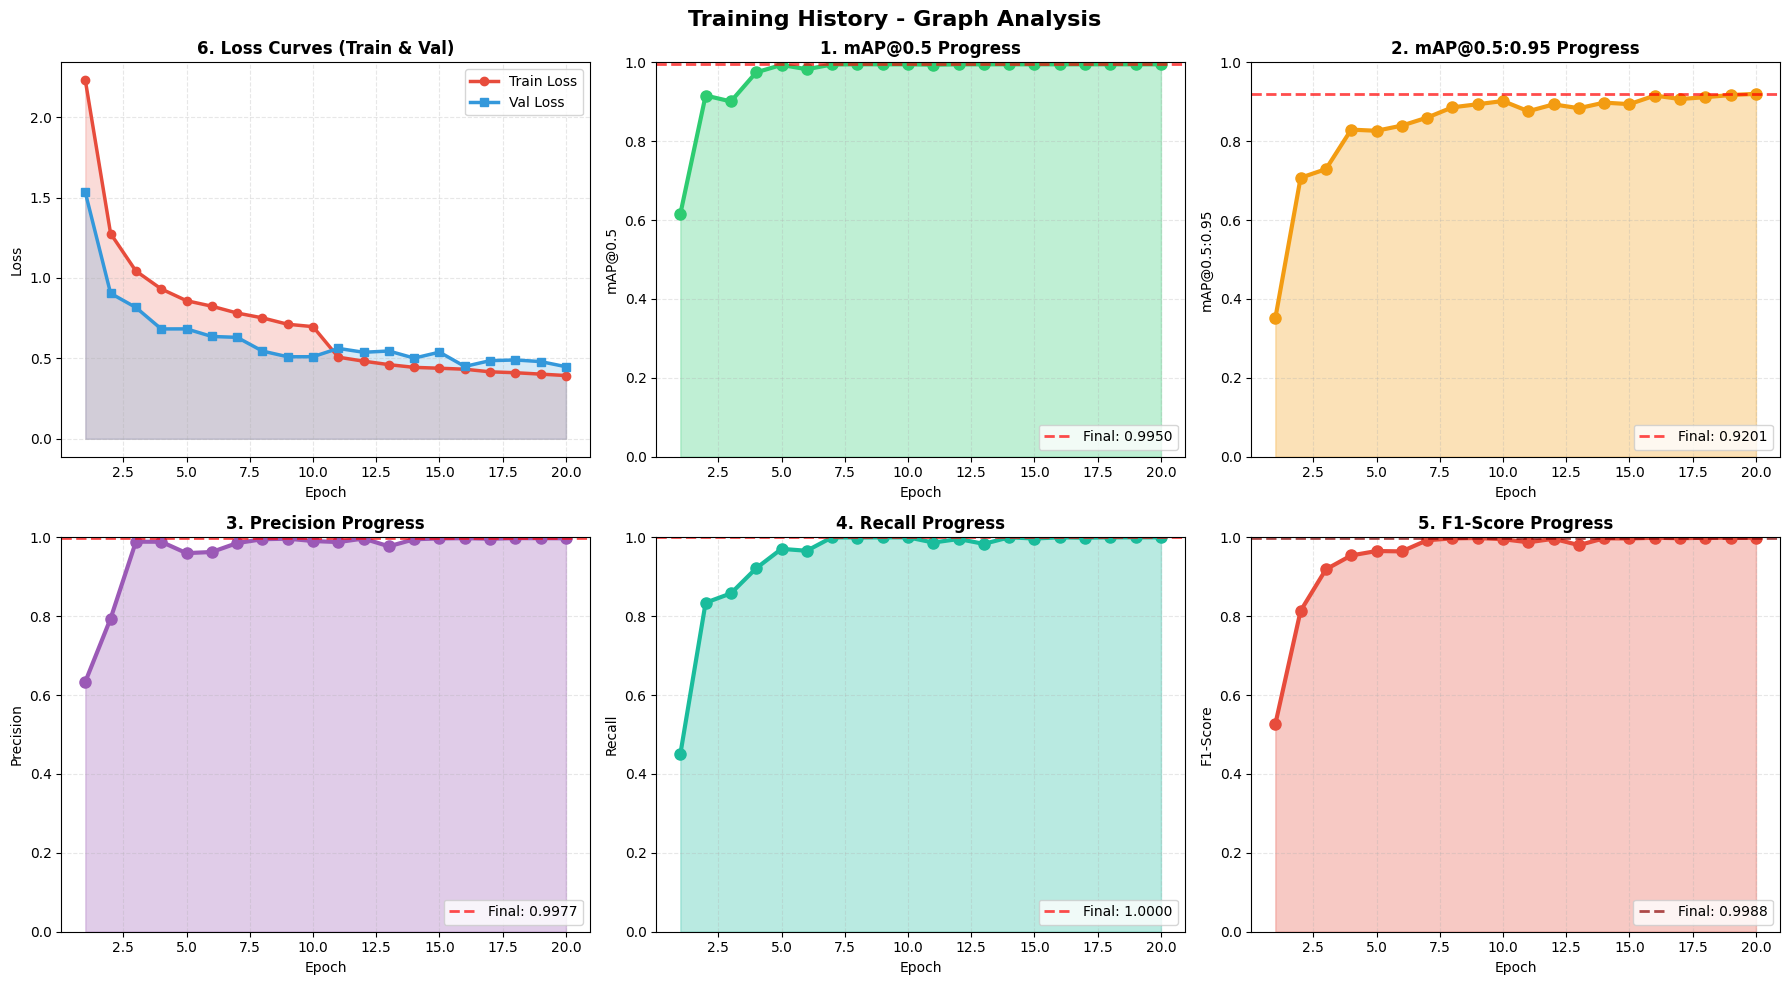

✅ Training history saved: /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/test_analysis_resultsinplot/training_history_graphs.png

📦 Loading model...
✅ Model loaded!

🧪 PART 2: TEST SET EVALUATION

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n_cbam summary (fused): 81 layers, 3,014,523 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 173.0±40.5 MB/s, size: 393.3 KB)
val: Scanning /content/drive/MyDrive/Major_Project/Images2700_10Feet_Detected/labels/test.cache... 240 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240 16.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.1it/s 7.1s
                   all        240        240          1          1      0.995      0.909
         Speed_Breaker         80         80          1          1      0.995      0.924
         Slippery_Road         80         80          1

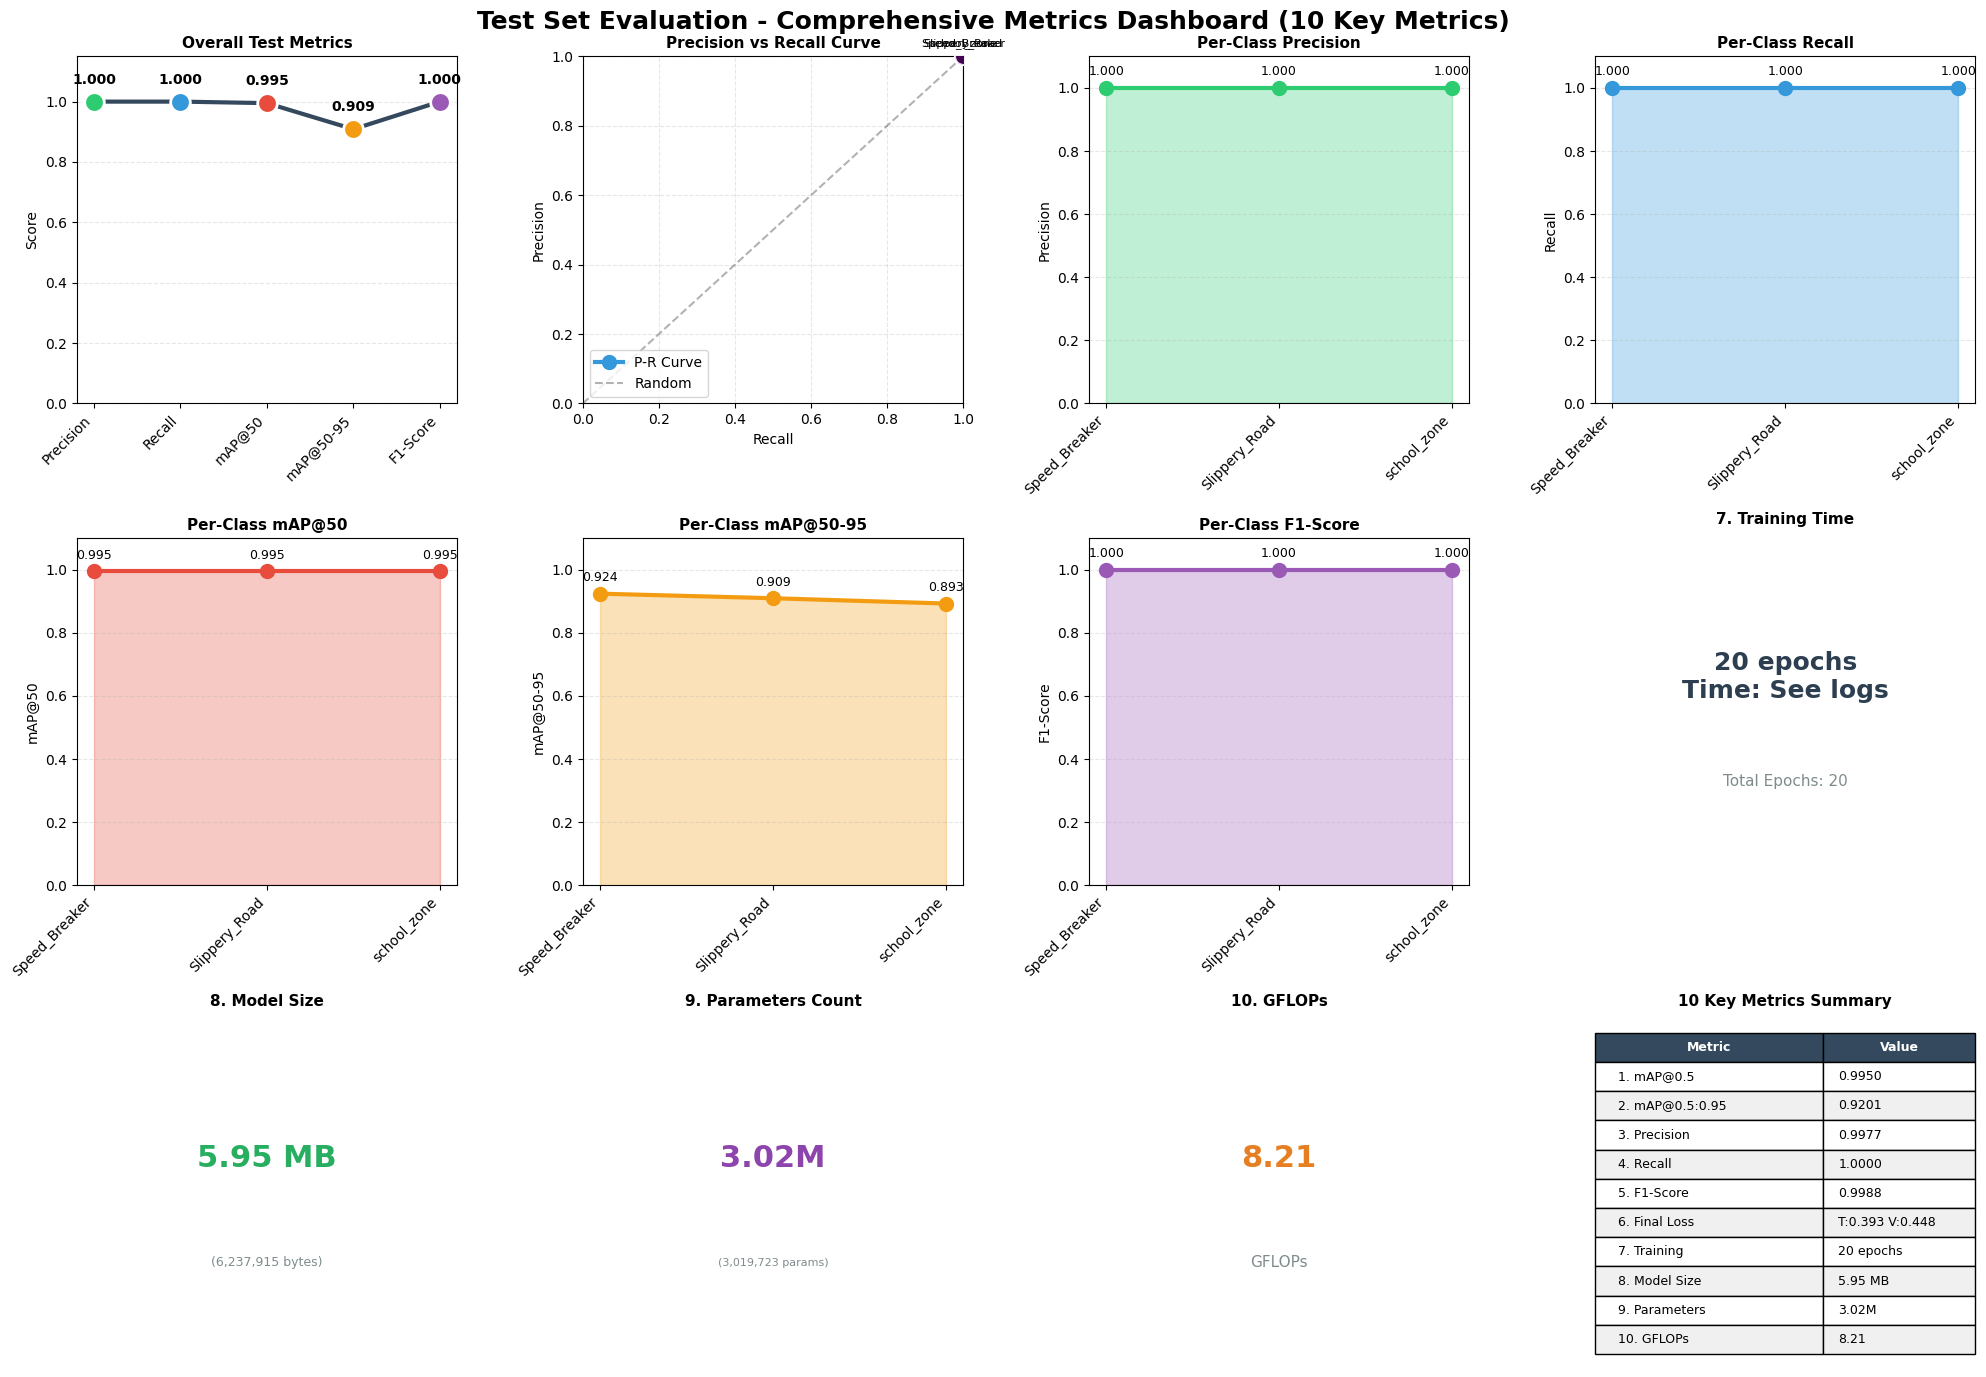

✅ Dashboard saved: /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/test_analysis_resultsinplot/comprehensive_test_metrics_10.png

💾 Saving results...
✅ Per-class metrics saved: /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/test_analysis_resultsinplot/per_class_test_metrics.csv

📋 PER-CLASS TEST METRICS
        Class  Precision  Recall  F1-Score  AP@50  AP@50-95
Speed_Breaker        1.0     1.0       1.0  0.995  0.923883
Slippery_Road        1.0     1.0       1.0  0.995  0.909425
  school_zone        1.0     1.0       1.0  0.995  0.892627
✅ Metrics saved: /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/test_analysis_resultsinplot/overall_test_metrics_10.txt

🎉 YOLO-CBAM ANALYSIS COMPLETE!

📁 Results saved in: /content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/test_analysis_resultsinplot/

✨ 10 Key Metrics Summary:
   1.  mAP@0.5      : 0.9950
   2.  mAP@0.5:0.95 : 0.9201
   3.  Precision    : 0.9977
   4.  Recall       : 1.0000
   5.  F1-Sc

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import os
import torch
import torch.nn as nn
import ultralytics.nn.tasks as tasks
import ultralytics.nn.modules as modules

# ===================== DEFINE CBAM MODULE =====================
# Must match EXACTLY how it was defined during training
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.ca = ChannelAttention(in_channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# ---- Register CBAM ----
tasks.CBAM = CBAM
modules.CBAM = CBAM
print("✅ CBAM registered")

# ===================== CONFIGURATION =====================
TRAINING_OUTPUT_DIR = "/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/Results"
DATASET_PATH        = "/content/drive/MyDrive/Major_Project/Images2700_10Feet_Detected"
TEST_OUTPUT_DIR     = "/content/drive/MyDrive/Major_Project/YOLO_Cbam_Architecture/test_analysis_resultsinplot"

Path(TEST_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

RESULTS_CSV      = f"{TRAINING_OUTPUT_DIR}/yolov8n_cbam/results.csv"
BEST_MODEL_PATH  = f"{TRAINING_OUTPUT_DIR}/yolov8n_cbam/weights/best.pt"
DATA_YAML        = f"{TRAINING_OUTPUT_DIR}/data.yaml"

print("="*100)
print("🎯 YOLO-CBAM MODEL - COMPLETE ANALYSIS WITH 10 KEY METRICS")
print("="*100)
print(f"\n📂 Configuration:")
print(f"   Training Results : {TRAINING_OUTPUT_DIR}")
print(f"   Dataset          : {DATASET_PATH}")
print(f"   Test Output      : {TEST_OUTPUT_DIR}")
print(f"   Model Weights    : {BEST_MODEL_PATH}")
print("="*100)

# ===================== INITIALIZE ALL VARIABLES =====================
epochs = None
train_box_loss = None
val_box_loss = None
map50_history = None
map5095_history = None
precision_history = None
recall_history = None
f1_history = None
metric_1_map50 = None
metric_2_map5095 = None
metric_3_precision = None
metric_4_recall = None
metric_5_f1_score = None
training_success = False

# ===================== PART 1: TRAINING HISTORY =====================
print("\n" + "="*100)
print("📊 PART 1: TRAINING HISTORY (Epoch-by-Epoch Metrics)")
print("="*100 + "\n")

try:
    df_train = pd.read_csv(RESULTS_CSV)
    df_train.columns = df_train.columns.str.strip()

    print("Training Metrics for All Epochs:")
    print("-" * 110)
    print("{:<8} {:<15} {:<15} {:<15} {:<15} {:<15} {:<15}".format(
        "Epoch", "Train Loss", "Val Loss", "Val mAP50", "Val mAP50-95", "Precision", "Recall"
    ))
    print("-" * 110)

    for idx, row in df_train.iterrows():
        print("{:<8} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f}".format(
            int(row['epoch']),
            row['train/box_loss'],
            row['val/box_loss'],
            row['metrics/mAP50(B)'],
            row['metrics/mAP50-95(B)'],
            row['metrics/precision(B)'],
            row['metrics/recall(B)']
        ))

    print("-" * 110)
    print(f"✅ Training completed with {len(df_train)} epochs")

    epochs             = df_train['epoch'].values
    train_box_loss     = df_train['train/box_loss'].values
    val_box_loss       = df_train['val/box_loss'].values
    map50_history      = df_train['metrics/mAP50(B)'].values
    map5095_history    = df_train['metrics/mAP50-95(B)'].values
    precision_history  = df_train['metrics/precision(B)'].values
    recall_history     = df_train['metrics/recall(B)'].values
    f1_history         = 2 * (precision_history * recall_history) / (precision_history + recall_history + 1e-6)

    final_epoch        = df_train.iloc[-1]
    metric_1_map50     = float(final_epoch['metrics/mAP50(B)'])
    metric_2_map5095   = float(final_epoch['metrics/mAP50-95(B)'])
    metric_3_precision = float(final_epoch['metrics/precision(B)'])
    metric_4_recall    = float(final_epoch['metrics/recall(B)'])
    metric_5_f1_score  = 2 * (metric_3_precision * metric_4_recall) / (metric_3_precision + metric_4_recall + 1e-6)

    training_success = True

    # ---- Training History Plots ----
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training History - Graph Analysis', fontsize=16, fontweight='bold')

    ax1 = axes[0, 0]
    ax1.plot(epochs, train_box_loss, 'o-', label='Train Loss', linewidth=2.5, markersize=6, color='#e74c3c')
    ax1.plot(epochs, val_box_loss,   's-', label='Val Loss',   linewidth=2.5, markersize=6, color='#3498db')
    ax1.fill_between(epochs, train_box_loss, alpha=0.2, color='#e74c3c')
    ax1.fill_between(epochs, val_box_loss,   alpha=0.2, color='#3498db')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('6. Loss Curves (Train & Val)', fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3, linestyle='--')

    ax2 = axes[0, 1]
    ax2.plot(epochs, map50_history, 'o-', color='#2ecc71', linewidth=3, markersize=8)
    ax2.fill_between(epochs, map50_history, alpha=0.3, color='#2ecc71')
    ax2.axhline(y=metric_1_map50, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Final: {metric_1_map50:.4f}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('mAP@0.5')
    ax2.set_title('1. mAP@0.5 Progress', fontweight='bold')
    ax2.legend(loc='lower right'); ax2.grid(True, alpha=0.3, linestyle='--'); ax2.set_ylim([0, 1])

    ax3 = axes[0, 2]
    ax3.plot(epochs, map5095_history, 'o-', color='#f39c12', linewidth=3, markersize=8)
    ax3.fill_between(epochs, map5095_history, alpha=0.3, color='#f39c12')
    ax3.axhline(y=metric_2_map5095, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Final: {metric_2_map5095:.4f}')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('mAP@0.5:0.95')
    ax3.set_title('2. mAP@0.5:0.95 Progress', fontweight='bold')
    ax3.legend(loc='lower right'); ax3.grid(True, alpha=0.3, linestyle='--'); ax3.set_ylim([0, 1])

    ax4 = axes[1, 0]
    ax4.plot(epochs, precision_history, 'o-', color='#9b59b6', linewidth=3, markersize=8)
    ax4.fill_between(epochs, precision_history, alpha=0.3, color='#9b59b6')
    ax4.axhline(y=metric_3_precision, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Final: {metric_3_precision:.4f}')
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Precision')
    ax4.set_title('3. Precision Progress', fontweight='bold')
    ax4.legend(loc='lower right'); ax4.grid(True, alpha=0.3, linestyle='--'); ax4.set_ylim([0, 1])

    ax5 = axes[1, 1]
    ax5.plot(epochs, recall_history, 'o-', color='#1abc9c', linewidth=3, markersize=8)
    ax5.fill_between(epochs, recall_history, alpha=0.3, color='#1abc9c')
    ax5.axhline(y=metric_4_recall, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Final: {metric_4_recall:.4f}')
    ax5.set_xlabel('Epoch'); ax5.set_ylabel('Recall')
    ax5.set_title('4. Recall Progress', fontweight='bold')
    ax5.legend(loc='lower right'); ax5.grid(True, alpha=0.3, linestyle='--'); ax5.set_ylim([0, 1])

    ax6 = axes[1, 2]
    ax6.plot(epochs, f1_history, 'o-', color='#e74c3c', linewidth=3, markersize=8)
    ax6.fill_between(epochs, f1_history, alpha=0.3, color='#e74c3c')
    ax6.axhline(y=metric_5_f1_score, color='darkred', linestyle='--', linewidth=2, alpha=0.7, label=f'Final: {metric_5_f1_score:.4f}')
    ax6.set_xlabel('Epoch'); ax6.set_ylabel('F1-Score')
    ax6.set_title('5. F1-Score Progress', fontweight='bold')
    ax6.legend(loc='lower right'); ax6.grid(True, alpha=0.3, linestyle='--'); ax6.set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig(f'{TEST_OUTPUT_DIR}/training_history_graphs.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Training history saved: {TEST_OUTPUT_DIR}/training_history_graphs.png")

except Exception as e:
    print(f"⚠️ Error loading training history: {e}")
    training_success = False

# ===================== LOAD MODEL =====================
print("\n📦 Loading model...")
model = YOLO(BEST_MODEL_PATH)
print("✅ Model loaded!")

# ---- Model Size ----
try:
    model_size_bytes       = os.path.getsize(BEST_MODEL_PATH)
    metric_8_model_size_mb = model_size_bytes / (1024 * 1024)
except:
    model_size_bytes       = 0
    metric_8_model_size_mb = 0.0

# ---- Parameters ----
try:
    metric_9_parameters = sum(p.numel() for p in model.model.parameters())
except:
    metric_9_parameters = None

# ---- GFLOPs ----
try:
    from ultralytics.utils.torch_utils import get_flops
    metric_10_gflops = get_flops(model.model)
except:
    try:
        info = model.info(verbose=False)
        metric_10_gflops = info[1]
    except:
        metric_10_gflops = None

# ===================== PART 2: TEST SET EVALUATION =====================
print("\n" + "="*100)
print("🧪 PART 2: TEST SET EVALUATION")
print("="*100 + "\n")

test_results = model.val(
    data=DATA_YAML,
    split='test',
    imgsz=640,
    batch=16,
    conf=0.25,
    iou=0.6,
    plots=True,
    save_json=True,
    project=TEST_OUTPUT_DIR,
    name='test_evaluation'
)
print("\n✅ Test evaluation completed!")

# ===================== EXTRACT TEST METRICS =====================
metrics = {
    'Precision' : test_results.box.mp,
    'Recall'    : test_results.box.mr,
    'mAP@50'    : test_results.box.map50,
    'mAP@50-95' : test_results.box.map,
    'F1-Score'  : 2 * (test_results.box.mp * test_results.box.mr) / (test_results.box.mp + test_results.box.mr + 1e-6),
}

if not training_success or metric_1_map50 is None:
    print("⚠️ Using test set metrics for metrics 1-5")
    metric_1_map50     = float(test_results.box.map50)
    metric_2_map5095   = float(test_results.box.map)
    metric_3_precision = float(test_results.box.mp)
    metric_4_recall    = float(test_results.box.mr)
    metric_5_f1_score  = float(metrics['F1-Score'])

per_class_metrics = {
    'Class'    : list(test_results.names.values()),
    'Precision': test_results.box.p.tolist()    if hasattr(test_results.box, 'p')    else [],
    'Recall'   : test_results.box.r.tolist()    if hasattr(test_results.box, 'r')    else [],
    'AP@50'    : test_results.box.ap50.tolist() if hasattr(test_results.box, 'ap50') else [],
    'AP@50-95' : test_results.box.ap.tolist()   if hasattr(test_results.box, 'ap')   else [],
}

print("\n" + "="*100)
print("🎯 FINAL TEST SET RESULTS")
print("="*100)
for k, v in metrics.items():
    print(f"{k:20s}: {v:.4f}")
print("="*100)

# ===================== PRINT 10 METRICS =====================
print("\n" + "="*100)
print("📈 10 KEY METRICS - FINAL RESULTS")
print("="*100)
print(f"\n{'Metric':<30} {'Value':<20}")
print("-" * 50)
print(f"{'1. mAP@0.5':<30} {metric_1_map50:.4f}")
print(f"{'2. mAP@0.5:0.95':<30} {metric_2_map5095:.4f}")
print(f"{'3. Precision':<30} {metric_3_precision:.4f}")
print(f"{'4. Recall':<30} {metric_4_recall:.4f}")
print(f"{'5. F1-Score':<30} {metric_5_f1_score:.4f}")
if train_box_loss is not None:
    print(f"{'6. Loss Curves':<30} Train: {train_box_loss[-1]:.4f}, Val: {val_box_loss[-1]:.4f}")
else:
    print(f"{'6. Loss Curves':<30} See training logs")
if epochs is not None:
    print(f"{'7. Training Time':<30} {len(epochs)} epochs")
else:
    print(f"{'7. Training Time':<30} See training logs")
print(f"{'8. Model Size (MB)':<30} {metric_8_model_size_mb:.2f} MB")
if metric_9_parameters:
    print(f"{'9. Parameters Count':<30} {metric_9_parameters:,} ({metric_9_parameters/1e6:.2f}M)")
if metric_10_gflops:
    print(f"{'10. GFLOPs':<30} {metric_10_gflops:.2f}")
print("="*100)

# ===================== COMPREHENSIVE DASHBOARD =====================
print("\n📊 Creating dashboard...")

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Test Set Evaluation - Comprehensive Metrics Dashboard (10 Key Metrics)',
             fontsize=18, fontweight='bold')

# 1. Overall Metrics
ax1 = plt.subplot(3, 4, 1)
metric_names  = list(metrics.keys())
metric_values = list(metrics.values())
x_pos  = np.arange(len(metric_names))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
ax1.plot(x_pos, metric_values, 'o-', linewidth=3, markersize=12, color='#34495e')
for i, (val, color) in enumerate(zip(metric_values, colors)):
    ax1.scatter(i, val, s=200, color=color, zorder=5, edgecolors='white', linewidths=2)
    ax1.text(i, val + 0.05, f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metric_names, rotation=45, ha='right')
ax1.set_ylim([0, 1.15]); ax1.set_ylabel('Score')
ax1.set_title('Overall Test Metrics', fontweight='bold', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

# 2. Precision-Recall Curve
ax2 = plt.subplot(3, 4, 2)
if len(per_class_metrics['Precision']) > 0:
    precisions = np.array(per_class_metrics['Precision'])
    recalls    = np.array(per_class_metrics['Recall'])
    classes    = per_class_metrics['Class']
    sort_idx   = np.argsort(recalls)
    ax2.plot(recalls[sort_idx], precisions[sort_idx], 'o-', linewidth=3, markersize=10, color='#3498db', label='P-R Curve')
    ax2.fill_between(recalls[sort_idx], precisions[sort_idx], alpha=0.3, color='#3498db')
    for i, cls in enumerate(classes):
        ax2.scatter(recalls[i], precisions[i], s=150, alpha=0.8, c=[i], cmap='viridis', edgecolors='white', linewidths=1.5, zorder=5)
        ax2.annotate(cls, (recalls[i], precisions[i]), fontsize=8, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
    ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1.5, label='Random')
    ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
    ax2.set_title('Precision vs Recall Curve', fontweight='bold', fontsize=11)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1]); ax2.legend(loc='lower left')

# 3. Per-Class Precision
ax3 = plt.subplot(3, 4, 3)
if len(per_class_metrics['Precision']) > 0:
    classes    = per_class_metrics['Class']
    precisions = per_class_metrics['Precision']
    x_pos_cls  = np.arange(len(classes))
    ax3.plot(x_pos_cls, precisions, 'o-', linewidth=3, markersize=10, color='#2ecc71')
    ax3.fill_between(x_pos_cls, precisions, alpha=0.3, color='#2ecc71')
    for i, val in enumerate(precisions):
        ax3.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax3.set_xticks(x_pos_cls); ax3.set_xticklabels(classes, rotation=45, ha='right')
    ax3.set_ylim([0, 1.1]); ax3.set_ylabel('Precision')
    ax3.set_title('Per-Class Precision', fontweight='bold', fontsize=11)
    ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

# 4. Per-Class Recall
ax4 = plt.subplot(3, 4, 4)
if len(per_class_metrics['Recall']) > 0:
    recalls_pc = per_class_metrics['Recall']
    ax4.plot(x_pos_cls, recalls_pc, 'o-', linewidth=3, markersize=10, color='#3498db')
    ax4.fill_between(x_pos_cls, recalls_pc, alpha=0.3, color='#3498db')
    for i, val in enumerate(recalls_pc):
        ax4.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax4.set_xticks(x_pos_cls); ax4.set_xticklabels(classes, rotation=45, ha='right')
    ax4.set_ylim([0, 1.1]); ax4.set_ylabel('Recall')
    ax4.set_title('Per-Class Recall', fontweight='bold', fontsize=11)
    ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

# 5. Per-Class mAP@50
ax5 = plt.subplot(3, 4, 5)
if len(per_class_metrics['AP@50']) > 0:
    ap50_values = per_class_metrics['AP@50']
    ax5.plot(x_pos_cls, ap50_values, 'o-', linewidth=3, markersize=10, color='#e74c3c')
    ax5.fill_between(x_pos_cls, ap50_values, alpha=0.3, color='#e74c3c')
    for i, val in enumerate(ap50_values):
        ax5.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax5.set_xticks(x_pos_cls); ax5.set_xticklabels(classes, rotation=45, ha='right')
    ax5.set_ylim([0, 1.1]); ax5.set_ylabel('mAP@50')
    ax5.set_title('Per-Class mAP@50', fontweight='bold', fontsize=11)
    ax5.grid(True, alpha=0.3, linestyle='--', axis='y')

# 6. Per-Class mAP@50-95
ax6 = plt.subplot(3, 4, 6)
if len(per_class_metrics['AP@50-95']) > 0:
    ap_values = per_class_metrics['AP@50-95']
    ax6.plot(x_pos_cls, ap_values, 'o-', linewidth=3, markersize=10, color='#f39c12')
    ax6.fill_between(x_pos_cls, ap_values, alpha=0.3, color='#f39c12')
    for i, val in enumerate(ap_values):
        ax6.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax6.set_xticks(x_pos_cls); ax6.set_xticklabels(classes, rotation=45, ha='right')
    ax6.set_ylim([0, 1.1]); ax6.set_ylabel('mAP@50-95')
    ax6.set_title('Per-Class mAP@50-95', fontweight='bold', fontsize=11)
    ax6.grid(True, alpha=0.3, linestyle='--', axis='y')

# 7. Per-Class F1-Score
ax7 = plt.subplot(3, 4, 7)
if len(per_class_metrics['Precision']) > 0 and len(per_class_metrics['Recall']) > 0:
    f1_scores = 2 * (np.array(per_class_metrics['Precision']) * np.array(per_class_metrics['Recall'])) / \
                (np.array(per_class_metrics['Precision']) + np.array(per_class_metrics['Recall']) + 1e-6)
    ax7.plot(x_pos_cls, f1_scores, 'o-', linewidth=3, markersize=10, color='#9b59b6')
    ax7.fill_between(x_pos_cls, f1_scores, alpha=0.3, color='#9b59b6')
    for i, val in enumerate(f1_scores):
        ax7.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax7.set_xticks(x_pos_cls); ax7.set_xticklabels(classes, rotation=45, ha='right')
    ax7.set_ylim([0, 1.1]); ax7.set_ylabel('F1-Score')
    ax7.set_title('Per-Class F1-Score', fontweight='bold', fontsize=11)
    ax7.grid(True, alpha=0.3, linestyle='--', axis='y')

# 8. Training Time
ax8 = plt.subplot(3, 4, 8)
ax8.axis('off')
time_text = f"{len(epochs)} epochs\nTime: See logs" if epochs is not None else "See training logs"
ax8.text(0.5, 0.6, time_text, ha='center', va='center', fontsize=18, fontweight='bold', color='#2c3e50')
if epochs is not None:
    ax8.text(0.5, 0.3, f'Total Epochs: {len(epochs)}', ha='center', va='center', fontsize=11, color='#7f8c8d')
ax8.set_title('7. Training Time', fontweight='bold', fontsize=11, pad=10)

# 9. Model Size
ax9 = plt.subplot(3, 4, 9)
ax9.axis('off')
ax9.text(0.5, 0.6, f'{metric_8_model_size_mb:.2f} MB', ha='center', va='center', fontsize=22, fontweight='bold', color='#27ae60')
ax9.text(0.5, 0.3, f'({model_size_bytes:,} bytes)', ha='center', va='center', fontsize=9, color='#7f8c8d')
ax9.set_title('8. Model Size', fontweight='bold', fontsize=11, pad=10)

# 10. Parameters
ax10 = plt.subplot(3, 4, 10)
ax10.axis('off')
if metric_9_parameters:
    ax10.text(0.5, 0.6, f'{metric_9_parameters/1e6:.2f}M', ha='center', va='center', fontsize=22, fontweight='bold', color='#8e44ad')
    ax10.text(0.5, 0.3, f'({metric_9_parameters:,} params)', ha='center', va='center', fontsize=8, color='#7f8c8d')
else:
    ax10.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=14, color='#7f8c8d')
ax10.set_title('9. Parameters Count', fontweight='bold', fontsize=11, pad=10)

# 11. GFLOPs
ax11 = plt.subplot(3, 4, 11)
ax11.axis('off')
if metric_10_gflops:
    ax11.text(0.5, 0.6, f'{metric_10_gflops:.2f}', ha='center', va='center', fontsize=22, fontweight='bold', color='#e67e22')
    ax11.text(0.5, 0.3, 'GFLOPs', ha='center', va='center', fontsize=11, color='#7f8c8d')
else:
    ax11.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=14, color='#7f8c8d')
ax11.set_title('10. GFLOPs', fontweight='bold', fontsize=11, pad=10)

# 12. Summary Table
ax12 = plt.subplot(3, 4, 12)
ax12.axis('off')
summary_data = [
    ['Metric',           'Value'],
    ['1. mAP@0.5',       f'{metric_1_map50:.4f}'],
    ['2. mAP@0.5:0.95',  f'{metric_2_map5095:.4f}'],
    ['3. Precision',     f'{metric_3_precision:.4f}'],
    ['4. Recall',        f'{metric_4_recall:.4f}'],
    ['5. F1-Score',      f'{metric_5_f1_score:.4f}'],
    ['6. Final Loss',    f'T:{train_box_loss[-1]:.3f} V:{val_box_loss[-1]:.3f}' if train_box_loss is not None else 'See logs'],
    ['7. Training',      f'{len(epochs)} epochs' if epochs is not None else 'See logs'],
    ['8. Model Size',    f'{metric_8_model_size_mb:.2f} MB'],
    ['9. Parameters',    f'{metric_9_parameters/1e6:.2f}M' if metric_9_parameters else 'N/A'],
    ['10. GFLOPs',       f'{metric_10_gflops:.2f}' if metric_10_gflops else 'N/A'],
]
table = ax12.table(cellText=summary_data[1:], colLabels=summary_data[0],
                   cellLoc='left', loc='center', colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)
for i in range(2):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')
for row in range(1, len(summary_data)):
    for col in range(2):
        if row % 2 == 0:
            table[(row, col)].set_facecolor('#f0f0f0')
ax12.set_title('10 Key Metrics Summary', fontweight='bold', pad=10, fontsize=11)

plt.tight_layout()
plt.savefig(f'{TEST_OUTPUT_DIR}/comprehensive_test_metrics_10.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Dashboard saved: {TEST_OUTPUT_DIR}/comprehensive_test_metrics_10.png")

# ===================== SAVE RESULTS =====================
print("\n💾 Saving results...")

if len(per_class_metrics['Precision']) > 0:
    df_test_results = pd.DataFrame({
        'Class'    : per_class_metrics['Class'],
        'Precision': per_class_metrics['Precision'],
        'Recall'   : per_class_metrics['Recall'],
        'F1-Score' : f1_scores.tolist(),
        'AP@50'    : per_class_metrics['AP@50'],
        'AP@50-95' : per_class_metrics['AP@50-95']
    })
    csv_path = f'{TEST_OUTPUT_DIR}/per_class_test_metrics.csv'
    df_test_results.to_csv(csv_path, index=False)
    print(f"✅ Per-class metrics saved: {csv_path}")
    print("\n" + "="*100)
    print("📋 PER-CLASS TEST METRICS")
    print("="*100)
    print(df_test_results.to_string(index=False))
    print("="*100)

with open(f'{TEST_OUTPUT_DIR}/overall_test_metrics_10.txt', 'w') as f:
    f.write("="*100 + "\n")
    f.write("YOLO-CBAM MODEL - FINAL TEST SET EVALUATION (10 KEY METRICS)\n")
    f.write("="*100 + "\n\n")
    f.write("PERFORMANCE METRICS:\n")
    f.write("-"*50 + "\n")
    f.write(f"1. mAP@0.5           : {metric_1_map50:.4f}\n")
    f.write(f"2. mAP@0.5:0.95      : {metric_2_map5095:.4f}\n")
    f.write(f"3. Precision         : {metric_3_precision:.4f}\n")
    f.write(f"4. Recall            : {metric_4_recall:.4f}\n")
    f.write(f"5. F1-Score          : {metric_5_f1_score:.4f}\n")
    if train_box_loss is not None:
        f.write(f"6. Final Train Loss  : {train_box_loss[-1]:.4f}\n")
        f.write(f"   Final Val Loss    : {val_box_loss[-1]:.4f}\n")
    else:
        f.write(f"6. Loss              : See training logs\n")
    f.write("\nMODEL CHARACTERISTICS:\n")
    f.write("-"*50 + "\n")
    if epochs is not None:
        f.write(f"7. Training Time     : {len(epochs)} epochs\n")
    else:
        f.write(f"7. Training Time     : See training logs\n")
    f.write(f"8. Model Size        : {metric_8_model_size_mb:.2f} MB\n")
    if metric_9_parameters:
        f.write(f"9. Parameters Count  : {metric_9_parameters:,} ({metric_9_parameters/1e6:.2f}M)\n")
    if metric_10_gflops:
        f.write(f"10. GFLOPs           : {metric_10_gflops:.2f}\n")
    f.write("\n" + "="*100 + "\n")
    f.write("MODEL: YOLOv8n + CBAM (Convolutional Block Attention Module)\n")
    f.write("="*100 + "\n")
print(f"✅ Metrics saved: {TEST_OUTPUT_DIR}/overall_test_metrics_10.txt")

# ===================== FINAL SUMMARY =====================
print("\n" + "="*100)
print("🎉 YOLO-CBAM ANALYSIS COMPLETE!")
print("="*100)
print(f"\n📁 Results saved in: {TEST_OUTPUT_DIR}/")
print("\n✨ 10 Key Metrics Summary:")
print(f"   1.  mAP@0.5      : {metric_1_map50:.4f}")
print(f"   2.  mAP@0.5:0.95 : {metric_2_map5095:.4f}")
print(f"   3.  Precision    : {metric_3_precision:.4f}")
print(f"   4.  Recall       : {metric_4_recall:.4f}")
print(f"   5.  F1-Score     : {metric_5_f1_score:.4f}")
if train_box_loss is not None:
    print(f"   6.  Loss         : Train={train_box_loss[-1]:.4f}, Val={val_box_loss[-1]:.4f}")
if epochs is not None:
    print(f"   7.  Training     : {len(epochs)} epochs")
print(f"   8.  Model Size   : {metric_8_model_size_mb:.2f} MB")
if metric_9_parameters:
    print(f"   9.  Parameters   : {metric_9_parameters/1e6:.2f}M")
if metric_10_gflops:
    print(f"   10. GFLOPs       : {metric_10_gflops:.2f}")
print("="*100)
print("🔥 Model: YOLOv8n + CBAM Attention Mechanism")
print("="*100)

In [ ]:
print("7. Training Time : 20 epochs completed in 0.530 hours.")

7. Training Time : 20 epochs completed in 0.530 hours.
